# First method, photonic qnn

### I° Photonic QNN overview

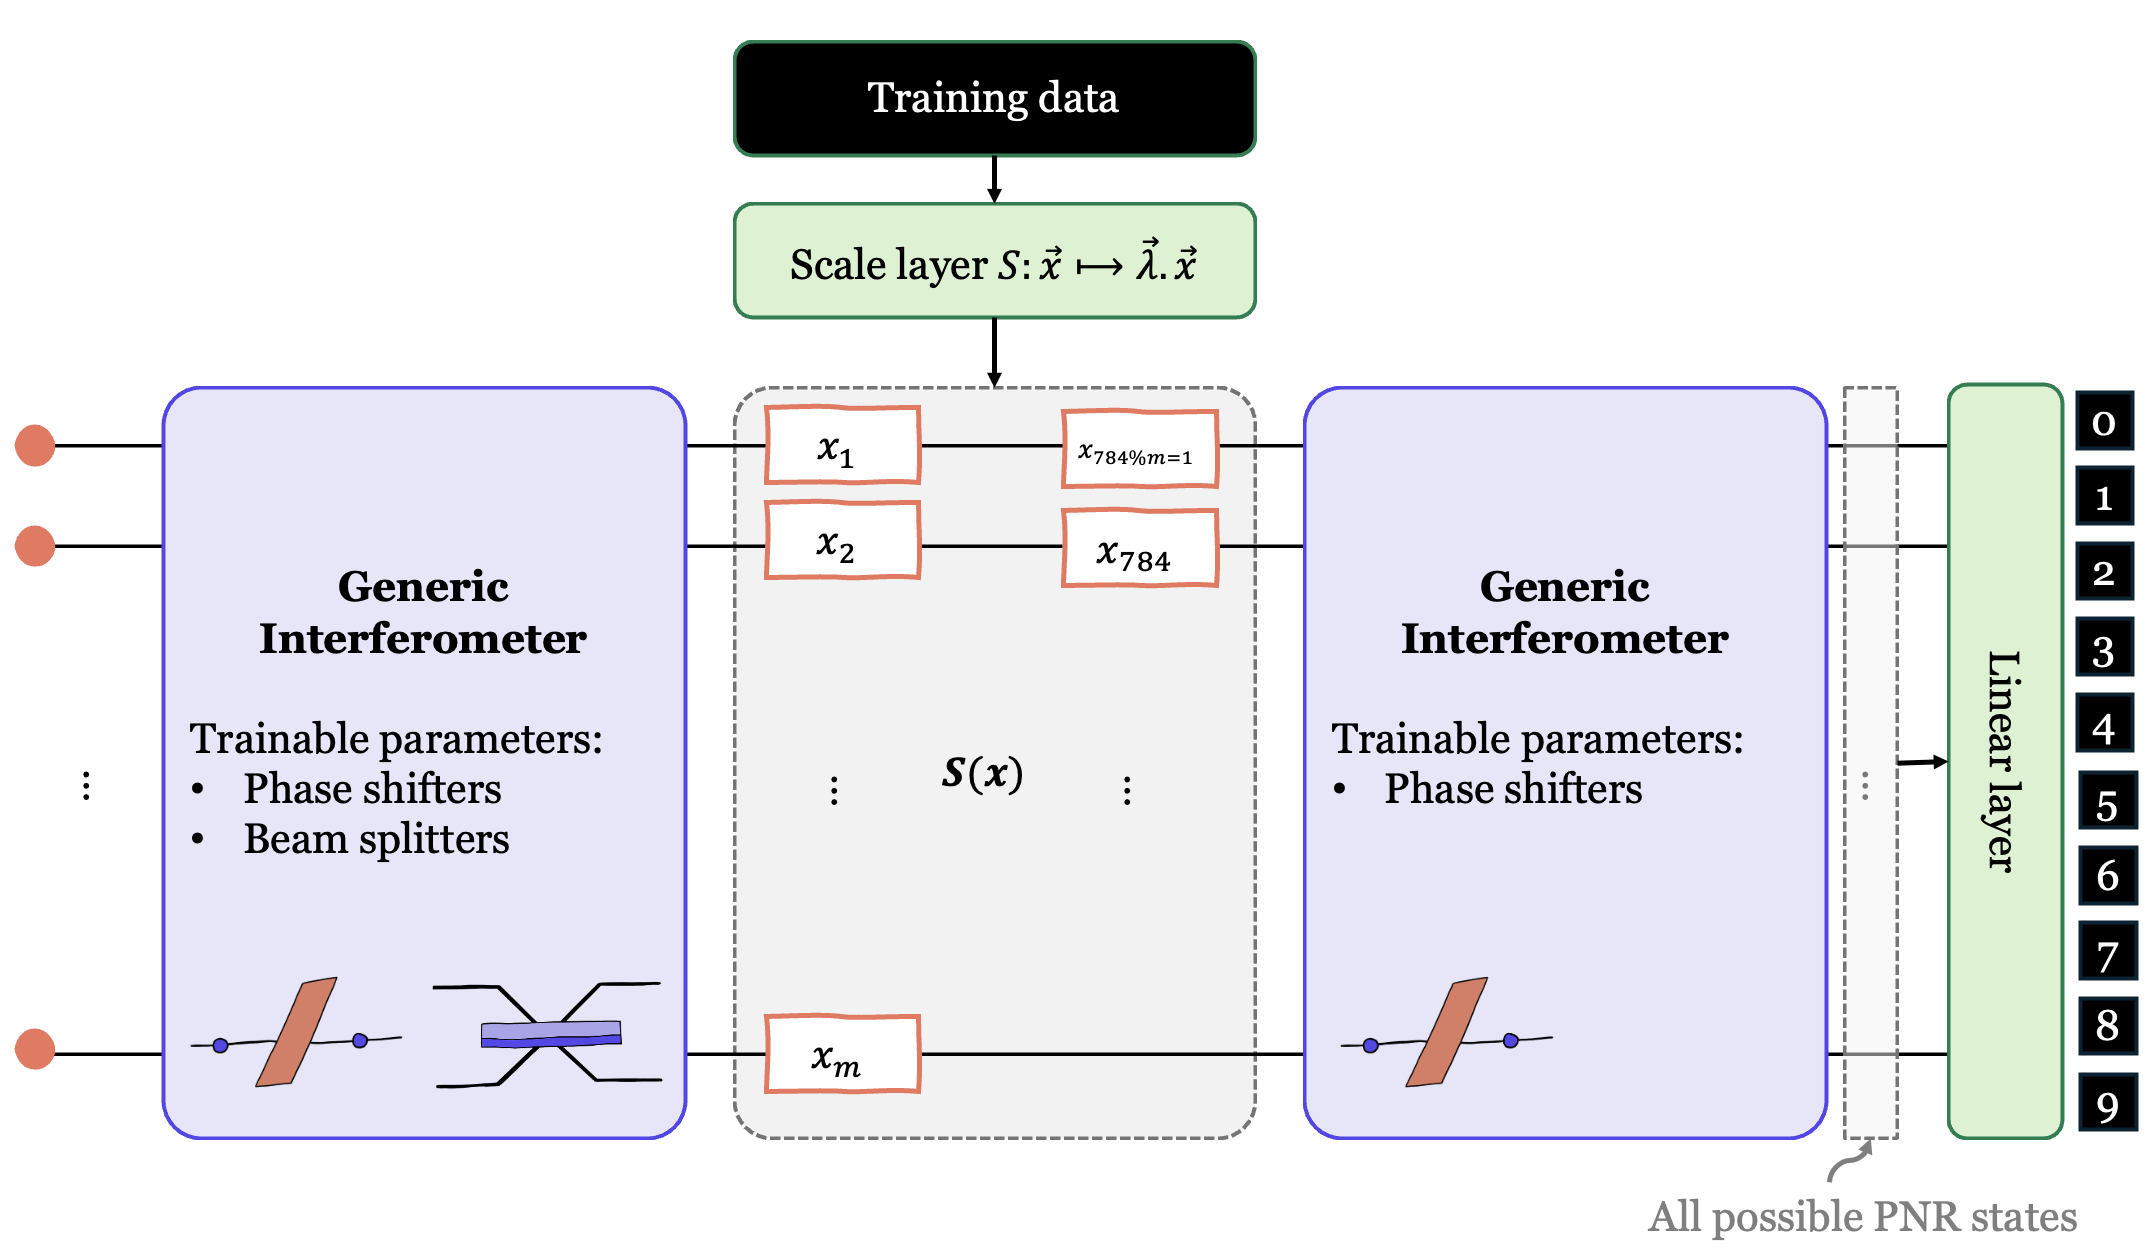

that's what the `create_quantum_circuit` function's do. we initialise a first generic interferometer, fully trainable, then an encoding layer not trainable, and lastly an interferometer which only phase shifters are trainable.

the trainable interferometer may need to rescale the input. that's why we have to construct the `ScaleLayer` class.

In [39]:
import math
import torch
import torch.nn as nn
import perceval as pcvl
from merlin import QuantumLayer
from merlin.measurement.strategies import MeasurementStrategy

###############################
## Build the quantum circuit ##
###############################

INPUT_SIZE = 32

def create_quantum_circuit(m, size=40, frequency=1):
    """Create quantum circuit with specified number of modes"""
    # first trainable generic interferometer
    wl = pcvl.GenericInterferometer(m,
                                    lambda i: pcvl.BS(theta=pcvl.P(f"bs_1_{i}")) // pcvl.PS(pcvl.P(f"phase_1_{i}")) // \
                                              pcvl.BS(theta=pcvl.P(f"bs_2_{i}")) // pcvl.PS(pcvl.P(f"phase_2_{i}")),
                                    shape=pcvl.InterferometerShape.RECTANGLE)
    

    c = pcvl.Circuit(m)
    c.add(0, wl, merge=True)

    # f repetition of {encoding layers with input data in phase shifters; trainable generic interferometer}
    for f in range(frequency):
        c_var = pcvl.Circuit(m)
        for i in range(size):
            px = pcvl.P(f"px-{f}-{i + 1}")
            c_var.add(i % m, pcvl.PS(px))
            
        c.add(0, c_var, merge=True)
        
        wr = pcvl.GenericInterferometer(m,
                                        lambda i: pcvl.BS() // pcvl.PS(pcvl.P(f"phase_3_{i}")) // \
                                                  pcvl.BS() // pcvl.PS(pcvl.P(f"phase_4_{i}")),
                                        shape=pcvl.InterferometerShape.RECTANGLE)
        c.add(0, wr, merge=True)

    return c


class ScaleLayer(nn.Module):
    def __init__(self, dim, scale_type = "learned"):
        super(ScaleLayer, self).__init__()
        # Create a single learnable parameter (initialized to 1.0 by default)
        # Caution: MerLin already mutltiplies by pi
        if scale_type == "learned":
            self.scale = nn.Parameter(torch.rand(dim))
        elif scale_type == "2pi":
            self.scale = torch.full((dim,), 2)
        elif scale_type == "pi":
            self.scale = torch.full((dim,), 1)
        elif scale_type == "1":
            self.scale = torch.full((dim,), 1)
        #print(f"SELF.SCALE: {self.scale.shape}")

    def forward(self, x):
        # Element-wise multiplication of each input element by the learned scale
        return x * self.scale

After the scale layer class construction, we can construct the core model, that we will use to make our classification.
we will use perceval to make the circuit, and package it into merlin's `QuantumLayer` class.

In [40]:
class QLayer(nn.Module):
    def __init__(self, nb_photons, nb_modes, dim, scale_type="learned"):
        super().__init__() 
        self.nb_modes = nb_modes
        self.nb_photons = nb_photons     
        self.scaler = ScaleLayer(dim, scale_type)

        circuit = create_quantum_circuit(m=nb_modes, size=dim, frequency=1)

        input_state = [(i + 1) % 2 for i in range(nb_modes)]

        self.layer = QuantumLayer(
        input_size=dim,
        circuit=circuit,
        input_state=input_state,
        measurement_strategy=MeasurementStrategy.probs(),
        input_parameters=["px"],
        trainable_parameters=["bs", "phase"], 
        )
    def forward(self, x):
        x = self.scaler(x)
        x = self.layer(x) 
        
        return x

We can set the seed to reproduce the results.

In [41]:
def set_seed(seed=42):
    """
    Set the random seed for reproducibility across different libraries.

    Args:
        seed (int): Seed value to use. Default is 42.
    """
    # Set Python's random seed
    random.seed(seed)

    # Set NumPy's random seed
    np.random.seed(seed)

    # Set PyTorch's random seeds for both CPU and CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # Additional settings for complete reproducibility
    # Note: This can affect performance
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For some PyTorch operations using Intel MKL
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"Random seed set to {seed}")

### II° and testing methods


first, we have to load the dataset and crop it to fit the model.

In [1]:
import perceval as pcvl
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import random
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import json
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from merlin.datasets import mnist_digits



class CustomToTensor:
    """
    Torch Tensor is not available with merlin 0.4, so we make a quick class to reliably replace toTensor method.
    
    """
    def __call__(self, pic):
        # Sécurité : forcer le type en numpy.ndarray si ce n'est pas déjà le cas
        if not isinstance(pic, np.ndarray):
            pic = np.array(pic)
            
        # 1. Réorganisation des dimensions si l'image a 3 dimensions (H, W, Canaux)
        if pic.ndim == 3:
            pic = pic.transpose((2, 0, 1))
            
        # 2. Conversion en tenseur PyTorch de type float
        img_tensor = torch.from_numpy(pic).float()
        
        # 3. Normalisation (seulement si l'image source était sur 8 bits)
        # Note : MNIST est souvent en uint8 [0, 255]
        if pic.dtype == np.uint8:
            img_tensor = img_tensor / 255.0
            
        return img_tensor


##########################
### load MNIST dataset ###
##########################

def crop_middle(image, size = 20):
    """
    Crop the middle from a numpy array based on the specified position.

    Args:
        image: Numpy array of shape (H, W, C) or (H, W)
        size: total size of the cropped image

    Returns:
        Cropped square numpy array
    """
    if len(image.shape) == 3:
        _, height, width = image.shape
    else:
        height, width = image.shape

    # Determine size of the square (the smaller dimension)
    mid_x = int(width * 0.5)
    mid_y = int(height * 0.5)
    half_size = int(size / 2)

    return image[mid_x-half_size:mid_x+half_size, mid_y-half_size:mid_y+half_size].copy()

class TransformCenter:
    def __init__(self, size = 20):
        self.transform = lambda x: crop_middle(x, size = size)
        self.tensor_transform = CustomToTensor()
        self.size = size

    def __call__(self, x):
        y1 = self.tensor_transform(self.transform(x)).view(self.size * self.size)
        return y1


# load the correct train, val dataset for the challenge, from the csv files
class MNIST_partial(Dataset):
    def __init__(self, data='./data', transform=None, split='train'):
        """
        Args:
            data: path to dataset folder which contains train.csv and val.csv
            transform (callable, optional): Optional transform to be applied
                on a sample (e.g., data augmentation or normalization)
            split: 'train' or 'val' to determine which set to download
        """
        self.data_dir = data
        self.transform = transform
        self.data = []

        if split == 'train':
            filename = os.path.join(self.data_dir, 'train.csv')
        elif split == 'val':
            filename = os.path.join(self.data_dir, 'val.csv')
        else:
            raise AttributeError("split!='train' and split!='val': split must be train or val")

        self.df = pd.read_csv(filename)

    def __len__(self):
        l = len(self.df['image'])
        return l

    def __getitem__(self, idx):
        img = self.df['image'].iloc[idx]
        label = self.df['label'].iloc[idx]
        # string to list
        img_list = re.split(r',', img)
        # remove '[' and ']'
        img_list[0] = img_list[0][1:]
        img_list[-1] = img_list[-1][:-1]
        # convert to float
        img_float = [float(el) for el in img_list]
        # convert to image
        img_square = torch.unflatten(torch.tensor(img_float), 0, (1, 28, 28)).numpy()
        #img_flat = img_square.flatten()
        if self.transform is not None:
            img_square = self.transform(img_square)
        return img_square, label


def load_dataset(size, bs):
    SIZE = size
    batch_size = bs

    # Load the Perceval Quest splits from the Merlin dataset helper
    X_train_raw, y_train_raw, _ = mnist_digits.get_data_train_percevalquest()
    X_val_raw, y_val_raw, _ = mnist_digits.get_data_test_percevalquest()

    # Crop a square at the centre of each image (SIZE x SIZE) and flatten it
    transform = TransformCenter(size=SIZE)
    X_train_flat = np.stack([transform(img).numpy() for img in X_train_raw]).astype(np.float32)
    X_val_flat = np.stack([transform(img).numpy() for img in X_val_raw]).astype(np.float32)

    y_train = np.asarray(y_train_raw, dtype=np.int64)
    y_val = np.asarray(y_val_raw, dtype=np.int64)

    # Feature-wise scaling (keeps behaviour identical to previous implementation)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_val_scaled = scaler.transform(X_val_flat)

    train_tensor = torch.from_numpy(X_train_scaled).float()
    val_tensor = torch.from_numpy(X_val_scaled).float()
    train_dataset = TensorDataset(train_tensor, torch.from_numpy(y_train))
    val_dataset = TensorDataset(val_tensor, torch.from_numpy(y_val))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    INPUT_SIZE = SIZE * SIZE
    OUTPUT_FEATURES = 10

    return X_train_scaled, X_val_scaled, y_train, y_val, train_loader, val_loader, INPUT_SIZE, OUTPUT_FEATURES


### III° training loop

we make the training loop for the photonic QNN

In [43]:
def train_model(model, train_loader, val_loader, num_epochs = 25, lr=0.01, frequency = 1, quantum = False):
    # train classical baseline
    criterion = nn.CrossEntropyLoss()
    # Betas from the ablation study
    optimizer = torch.optim.Adam(model.parameters(),lr = lr, betas=(0.8, 0.999))
    all_losses = []
    all_test_losses = []
    all_train_accuracies = []
    all_val_accuracies = []
    best_val_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        total_test_loss = 0
        correct = 0
        total = 0
        train_acc = 0
        for batch_X, batch_y in tqdm(train_loader):
            # Forward pass
            batch_X = batch_X.repeat(1, 1, frequency)
            if quantum:
                batch_X = batch_X
            outputs = model(batch_X.squeeze(0).float())
            loss = criterion(outputs, batch_y) #.view(-1, 1).float()
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            # Update tqdm with current metrics
            current_accuracy = 100 * correct / total
            train_acc += current_accuracy
        model.eval()
        correct_test = 0
        total_test = 0
        val_acc = 0
        #for batch_X, batch_y in val_loader:
        for batch_X, batch_y in tqdm(val_loader):
            batch_X = batch_X.repeat(1, 1, frequency)
            if quantum:
                batch_X = batch_X
            outputs = model(batch_X.squeeze(0).float())
            test_loss = criterion(outputs, batch_y) #.view(-1, 1).float()
            total_test_loss += test_loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_test += batch_y.size(0)
            correct_test += (predicted == batch_y).sum().item()

            current_test_accuracy = 100 * correct_test / total_test
            val_acc += current_test_accuracy
        val_acc_epoch = val_acc / len(val_loader)
        train_acc_epoch = train_acc / len(train_loader)
        if val_acc_epoch > best_val_acc:
            best_val_acc = val_acc_epoch
        # Print progress
        avg_loss = total_loss / len(train_loader)
        avg_test_loss = total_test_loss / len(val_loader)
        print(
            f'Epoch [{epoch + 1}/{num_epochs}], Train loss: {avg_loss:.4f}, Test loss: {avg_test_loss:.4f}, Train acc: {train_acc_epoch:.4f}, Test acc: {val_acc_epoch:.4f}, Best val acc: {best_val_acc:.4f}')

        all_losses.append(avg_loss)
        all_test_losses.append(avg_test_loss)
        all_train_accuracies.append(train_acc_epoch)
        all_val_accuracies.append(val_acc_epoch)

    return all_losses, all_test_losses, best_val_acc, all_train_accuracies, all_val_accuracies


# count paramaeters in a model (nn.Module)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)




### IV°/ Test and results

Once the training loop is done, we will be using confusion matrices to test the different models.
tSNE will be used to show the results of the model, by extracting features vi `extract_features` function, and ploting it with
`display_tsne`
we will also visualize the scale parameters of the encoding function and then save the results.


In [1]:

#############################
### results visualisation ###
#############################
## here, we want to visualize the scale parameters of the encoding function ##
def visualize_scale_parameters(scale_layer):
    """
        Display scale parameters of the encoding layers.

        Args:
            scale_layer (nn.Module): encoding layer
        """
    # Get the scale parameter data as a numpy array
    scale_data = scale_layer.scale.data.cpu().numpy()

    # For a single scale parameter
    if scale_data.size == 1:
        print(f"Learned scale parameter: {scale_data.item():.4f}")

    # For a 1D array of parameters (e.g., per feature)
    elif len(scale_data.shape) == 1 or (
            len(scale_data.shape) > 1 and np.prod(scale_data.shape) == max(scale_data.shape)):
        # Reshape to 1D if necessary
        scale_data = scale_data.flatten()

        plt.figure(figsize=(10, 6))

        # Option 1: Bar plot
        plt.subplot(2, 1, 1)
        plt.bar(range(len(scale_data)), scale_data)
        plt.title('Learned Scale Parameters')
        plt.xlabel('Parameter Index')
        plt.ylabel('Value')

        # Option 2: Heatmap (1D version)
        plt.subplot(2, 1, 2)
        sns.heatmap(scale_data.reshape(1, -1), cmap='viridis', annot=True if len(scale_data) < 20 else False)
        plt.title('Scale Parameters Heatmap')
        plt.xlabel('Parameter Index')

        plt.tight_layout()
        plt.savefig('scale_parameters.png')
        plt.show()

## display the confusion matrices for the 2 models ##
def display_confusion_matrices(model1, model2, val_loader, class_names=None, device='cuda'):
    """
    Display confusion matrices for two trained models using a validation data loader.

    Args:
        3 models : 3 PyTorch model
        val_loader: PyTorch DataLoader containing validation data
        class_names: List of class names (optional)
        device: Device to run inference on ('cuda' or 'cpu')
    """
    # Set models to evaluation mode
    model1.eval()
    model2.eval()

    # Move models to the appropriate device
    model1 = model1.to(device)
    model2 = model2.to(device)

    # Initialize lists to store predictions and ground truth
    all_preds1 = []
    all_preds2 = []
    all_targets = []

    # Disable gradient computation for inference
    with torch.no_grad():
        for inputs, targets in val_loader:

            targets = targets.to(device)

            # Get predictions from both models
            # outputs1 = model1(inputs.squeeze(1).float())
            # outputs2 = model2(inputs.squeeze(1).float())
            outputs1 = model1((inputs.squeeze(1).float()))
            outputs2 = model2((inputs.squeeze(1).float()))

            # Convert outputs to class predictions
            _, preds1 = torch.max(outputs1, 1)
            _, preds2 = torch.max(outputs2, 1)

            # Append batch predictions and targets to lists
            all_preds1.extend(preds1.cpu().numpy())
            all_preds2.extend(preds2.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds1 = np.array(all_preds1)
    all_preds2 = np.array(all_preds2)
    all_targets = np.array(all_targets)

    # Compute confusion matrices
    cm1 = confusion_matrix(all_targets, all_preds1)
    cm2 = confusion_matrix(all_targets, all_preds2)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Display confusion matrices
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)

    disp1.plot(ax=ax1, cmap='coolwarm', values_format='d')
    disp2.plot(ax=ax2, cmap='coolwarm', values_format='d')

    # Set titles
    ax1.set_title('Confusion Matrix - quantum Trained model')
    ax2.set_title('Confusion Matrix - classical Trained model')

    # Add overall accuracy to the titles
    acc1 = np.sum(np.diag(cm1)) / np.sum(cm1)
    acc2 = np.sum(np.diag(cm2)) / np.sum(cm2)

    ax1.set_xlabel(f'Predicted Label\nAccuracy: {acc1:.4f}')
    ax2.set_xlabel(f'Predicted Label\nAccuracy: {acc2:.4f}')

    plt.tight_layout()
    #plt.savefig(f'./results/CM-h-{hidden_dim}-m-{modes}.png')
    plt.show()

    return cm1, cm2

## extract features from a trained model for tSNE analysis ##
def extract_features(model, dataloader, device='cuda'):
    """
        Extract features using a trained model.

        Args:
            models : PyTorch model from which to extract features
            dataloader: dataloader containing training/validation data
            device: Device to run inference on ('cuda' or 'cpu')

        Returns:
            features: TorchTensor
            labels: TorchTensor
    """
    model.eval()  # Set the model to evaluation mode
    features = []
    labels = []

    with torch.no_grad():
        for data, label in dataloader:
            BS = data.shape[0]
            data = data.reshape(BS,-1).to(device)
            #print(f"\nData = {data}")
            output = model(data.float())
            features.append(output.cpu())  # Move to CPU for compatibility
            labels.extend(label.cpu().numpy())

    features = torch.cat(features, dim=0).numpy()
    labels = torch.tensor(labels).numpy()
    return features, labels


## display the tSNE plots for 2 models and dataloader ##
def display_tsne(model1, model2, val_loader,modes, device='cpu'):
    """
    Display the 3 tSNE for 3 trained models using a validation data loader.

    Args:
        the 2 models: 2 PyTorch models we want to compare
        val_loader: PyTorch DataLoader containing validation data
        modes: number used for the quantum model (for the Figure title)
        device: Device to run inference on ('cuda' or 'cpu')
    """
    # Set models to evaluation mode
    model1.eval()
    model2.eval()

    # Move models to the appropriate device
    model1 = model1.to(device)
    model2 = model2.to(device)

    # get the features and compute tSNE for each model
    features_1, labels_1 = extract_features(model1, val_loader, device=device)
    tsne = TSNE(n_components=2, random_state=42)
    features_2d_1 = tsne.fit_transform(features_1)

    features_2, labels_2 = extract_features(model2, val_loader, device=device)
    tsne = TSNE(n_components=2, random_state=42)
    features_2d_2 = tsne.fit_transform(features_2)


    # Display the tSNE plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    num_classes = 10
    for class_idx in range(num_classes):
        ax1.scatter(features_2d_1[labels_1 == class_idx, 0], features_2d_1[labels_1 == class_idx, 1],
                    label=f'Digit {class_idx}', alpha=0.6)
        ax1.set_xlabel('t-SNE Dim 1')
        ax1.set_ylabel('t-SNE Dim 2')
        ax1.legend()
        ax2.scatter(features_2d_2[labels_2 == class_idx, 0], features_2d_2[labels_2 == class_idx, 1],
                    label=f'Digit {class_idx}', alpha=0.6)
        ax2.set_xlabel('t-SNE Dim 1')
        ax2.set_ylabel('t-SNE Dim 2')
        ax2.legend()

    # Set titles
    ax1.set_title('tSNE - quantum kernel')
    ax2.set_title('tSNE - classical kernel model')
    plt.tight_layout()
    plt.savefig(f'tSNE-m-{modes}.png')
    #plt.show()

    return "done"

def save_experiment_results(results, filename='photonic_qNN_results.json'):
    """
    Append experiment results to a JSON file.

    Args:
        results (dict): Dictionary containing experiment results (with float values)
        filename (str): Path to the JSON file to store results
    """
    # Check if file exists and load existing data
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as file:
                all_results = json.load(file)
        except json.JSONDecodeError:
            # Handle case where file exists but is empty or corrupted
            all_results = []
    else:
        all_results = []

    # Append new results
    all_results.append(results)

    # Write updated data back to file
    with open(filename, 'w') as file:
        json.dump(all_results, file, indent=4)

    return len(all_results)

### V°/ Main loop

the different training paramaters are :
    `batch_size` : size of the batches.
    `size` : the size of the encoding layer.
    `pca_comp` : The number of components resulting from pca.
    `pca_enabled` : boolean to enable pca
    `display` : boolean to display number of paramters, the results.
    `FREQUENCY` : number ofphase shifters in the encoding layer.
    `MODES` : number of modes.
    `epochs`: number of epochs.
    `lr` : learning rate.
At first, we load the datasets and reduce the paramaters (if pca enabled), then we initiate the quantum layer and show the parameters. We also initiate a classical model and an svm to compare with the model. we lauch the training loop, plot and save the results.


Random seed set to 42

 Loading dataset...
... data loader with input size = 784
 - training statistics: 
 - X_train: (6000, 784) 
 - X_val: (600, 784)

 - Extracting PCA components
torch.Size([6000, 40])
tensor([0.4309, 0.8457, 0.6219, 0.1639, 0.8497, 0.3872, 0.2632, 0.8520, 0.4542,
        0.3130, 0.6797, 0.7341, 0.1836, 0.8542, 0.2123, 0.2716, 0.6835, 0.5003,
        0.5657, 0.8262, 0.7604, 0.4670, 0.3492, 0.5485, 0.5509, 0.6220, 0.3030,
        0.7560, 0.7189, 0.3557, 0.3678, 0.6472, 0.5085, 0.2901, 0.6294, 0.3622,
        0.8265, 0.2789, 0.6888, 0.3700])

 - Building the photonic quantum neural network...
input state: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


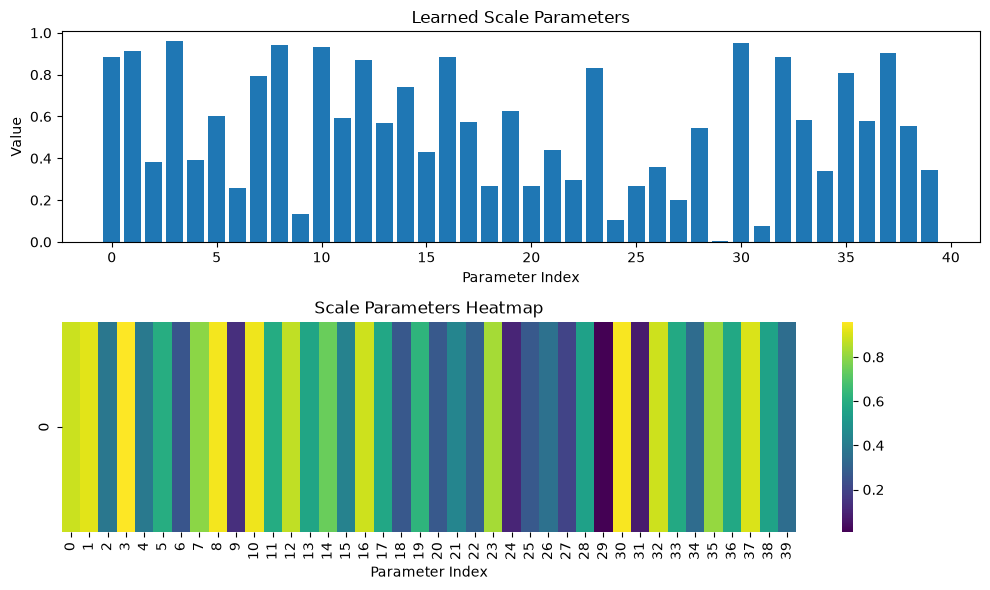

... Model built
 --- Training the quantum NN


100%|██████████| 10/10 [00:00<00:00, 20.23it/s]


Epoch [1/32], Train loss: 1.7491, Test loss: 1.4838, Train acc: 27.9648, Test acc: 50.7366, Best val acc: 50.7366


100%|██████████| 10/10 [00:00<00:00, 19.86it/s]


Epoch [2/32], Train loss: 1.2129, Test loss: 1.0764, Train acc: 57.4743, Test acc: 69.9407, Best val acc: 69.9407


...

Epoch [30/32], Train loss: 0.5786, Test loss: 0.6565, Train acc: 82.1783, Test acc: 79.1655, Best val acc: 82.6950


100%|██████████| 10/10 [00:00<00:00, 14.40it/s]


Epoch [31/32], Train loss: 0.5842, Test loss: 0.6857, Train acc: 80.0981, Test acc: 77.9423, Best val acc: 82.6950


100%|██████████| 10/10 [00:00<00:00, 14.55it/s]


Epoch [32/32], Train loss: 0.5764, Test loss: 0.5457, Train acc: 80.6543, Test acc: 83.0318, Best val acc: 83.0318


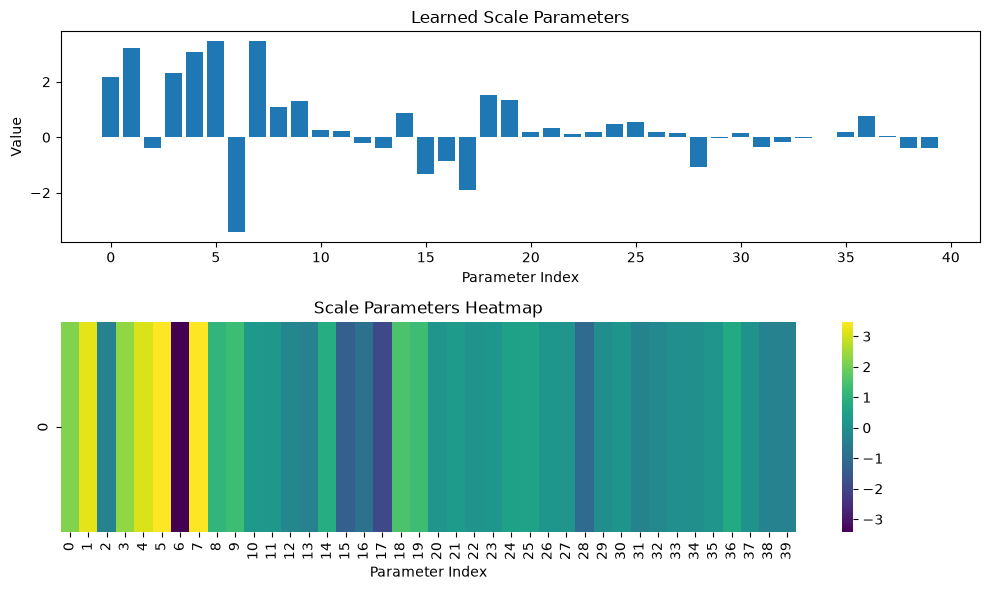

 --- Training the classical NN (linear)


100%|██████████| 10/10 [00:00<00:00, 651.25it/s]


Epoch [1/32], Train loss: 2.1366, Test loss: 1.9559, Train acc: 22.6336, Test acc: 59.4664, Best val acc: 59.4664


100%|██████████| 10/10 [00:00<00:00, 627.74it/s]


Epoch [2/32], Train loss: 1.8175, Test loss: 1.7757, Train acc: 66.8634, Test acc: 76.6809, Best val acc: 76.6809


...

Epoch [30/32], Train loss: 1.5654, Test loss: 1.5904, Train acc: 89.9772, Test acc: 88.5864, Best val acc: 89.3156


100%|██████████| 10/10 [00:00<00:00, 542.68it/s]


Epoch [31/32], Train loss: 1.5618, Test loss: 1.5787, Train acc: 90.9584, Test acc: 89.0084, Best val acc: 89.3156


100%|██████████| 10/10 [00:00<00:00, 500.16it/s]


Epoch [32/32], Train loss: 1.5628, Test loss: 1.5765, Train acc: 90.3994, Test acc: 89.1566, Best val acc: 89.3156
--- APPLYING a SVM ---
 -> Validation Accuracy after SVM: 0.9583333333333334
--- SVM applied ---
 - TRAINING IS DONE - 
 - Best validation accuracy for the quantum kernel = 83.0318 (for 2840 parameters), 
 - Best validation accuracy for the linear kernel = 89.3156 (for 1642 parameters)

 - Computing the confusion matrices...


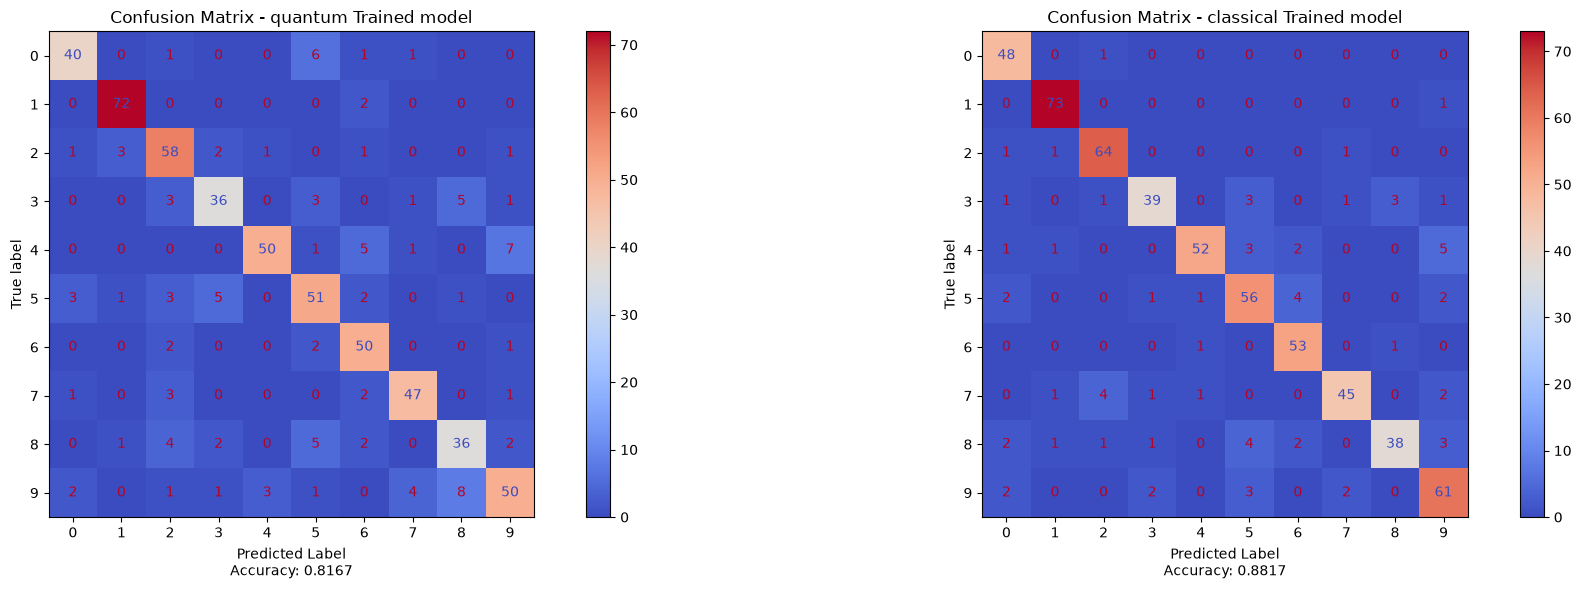

 - Computing the tSNE plots

 - Saving results...
Results saved !

EXPERIMENT COMPLETE !


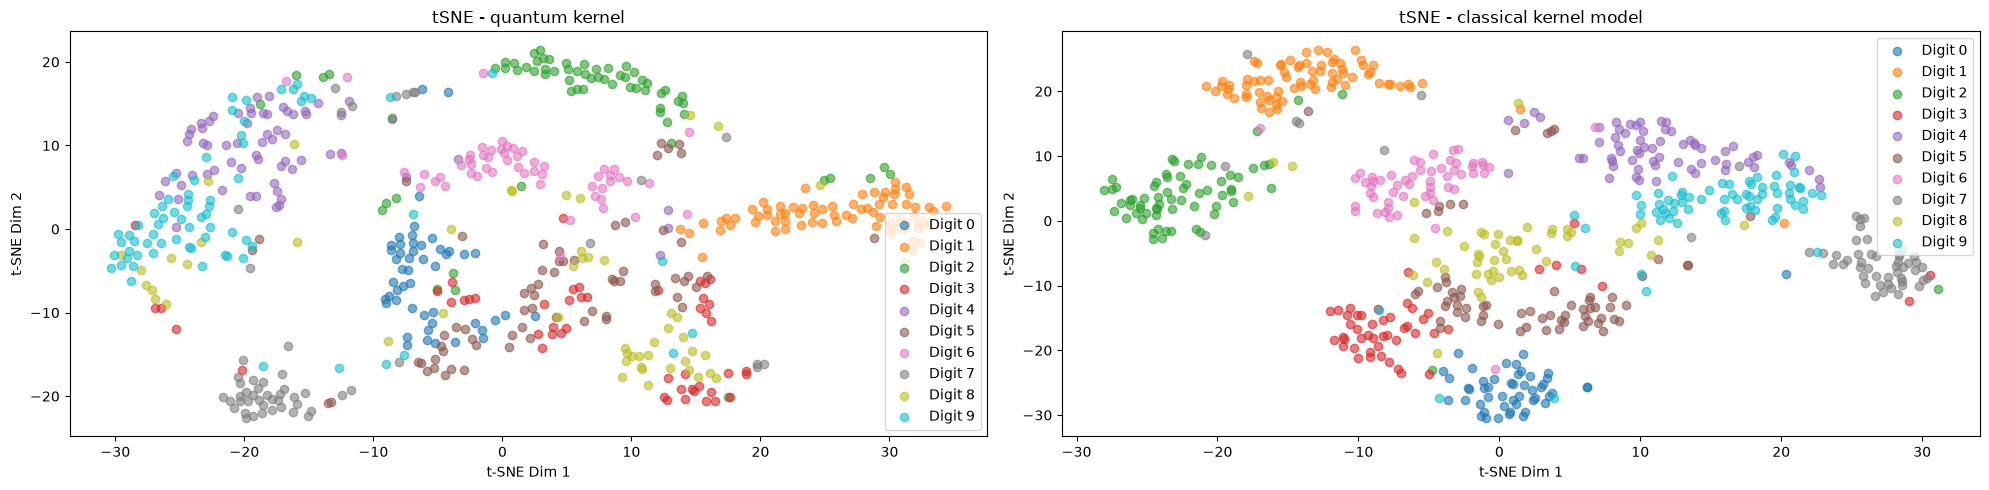

In [45]:
import math
from sklearn import svm
from sklearn.decomposition import PCA


def main():
    set_seed(42)

    batch_size = 64
    size = 28
    pca_comp = 40
    pca_enabled = True
    display = True
    FREQUENCY = 1
    MODES = 10
    epochs = 32
    lr = 0.05
    
    
    # load data
    print("\n Loading dataset...")
    X_train,X_val,y_train,y_val, train_loader,val_loader, INPUT_SIZE, OUTPUT_FEATURES = load_dataset(size, batch_size)
    print(f"... data loader with input size = {INPUT_SIZE}")
    print(f" - training statistics: \n - X_train: {X_train.shape} \n - X_val: {X_val.shape}")

    # Reduce to desired number of components (e.g., 40)
    if pca_enabled:
        print("\n - Extracting PCA components")
        n_components = pca_comp
        pca = PCA(n_components=n_components)

        X_pca = pca.fit_transform(X_train.reshape(X_train.shape[0], size*size))
        X_val_pca = pca.transform(X_val.reshape(X_val.shape[0], size*size))

        X_pca = torch.sigmoid(torch.FloatTensor(X_pca))
        X_val_pca = torch.sigmoid(torch.FloatTensor(X_val_pca))
        print(X_pca.shape)
        print(X_pca[2])

        train_dataset = TensorDataset(X_pca, torch.LongTensor(y_train))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_dataset = TensorDataset(X_val_pca, torch.LongTensor(y_val))
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        INPUT_SIZE = n_components

    ##################
    ## photonic qNN ##
    ##################
    print("\n - Building the photonic quantum neural network...")
    input_state = [(i + 1) % 2 for i in range(MODES)]
    photons_count = sum(input_state)
    print(f"input state: {input_state}")
    
    Q_Layer = QLayer(photons_count, MODES, INPUT_SIZE*FREQUENCY, scale_type="learned")


    # learnable layer to map to the correct number of classes
    #classification_layer = nn.Linear(in_features=math.comb(MODES + photons_count-1,photons_count), out_features=OUTPUT_FEATURES,
    #                                 bias=True)
    classification_layer = nn.Linear(in_features=math.comb(MODES, photons_count), out_features=OUTPUT_FEATURES, bias=True)
    # input layer that multiplies the input by a learned encoding
    # input_layer = ScaleLayer(INPUT_SIZE*FREQUENCY, scale_type="learned")
    
   # Q_Layer = QLayer(photons_count, MODES, size*FREQUENCY, scale_type="learned")
    if display:
        visualize_scale_parameters(Q_Layer.scaler)
    #nn.init.xavier_uniform_(classification_layer.weight)
    #nn.init.constant_(classification_layer.bias, 0.0)
    # create q_model as nn.Module
    q_model = nn.Sequential(Q_Layer, classification_layer)
    print("... Model built")

    ########################
    ## classical NN (MLP) ##
    ########################
    # 2 layers with ReLU activation
    layer_1 = nn.Linear(in_features=INPUT_SIZE, out_features=32, bias=True)
    layer_2 = nn.Linear(in_features=32, out_features=OUTPUT_FEATURES, bias=True)
    model = nn.Sequential(layer_1, nn.ReLU(), layer_2, nn.Softmax(dim=1))

    #########################
    ## Training the models ##
    #########################

    EPOCHS = epochs
    LR = lr

    print(f" --- Training the quantum NN")

    q_train_losses, q_val_losses, best_q_acc, q_train_accs, q_val_accs = train_model(q_model, train_loader, val_loader, num_epochs=EPOCHS, lr = LR, frequency = FREQUENCY, quantum = True)
    if display:
        visualize_scale_parameters(q_model[0].scaler)
        # save qLayer if needed
        #torch.save(q_model[0].state_dict(), 'scale_layer_trained_5.pt')

    # train classical baseline
    print(f" --- Training the classical NN (linear)")
    cl_train_losses, cl_val_losses, best_cl_acc, cl_train_accs, cl_val_accs = train_model(model, train_loader, val_loader, num_epochs=EPOCHS, lr = 0.01)

    ### APPLY SVM ###
    print("--- APPLYING a SVM ---")
    clf = svm.SVC()
    clf.fit(X_train, y_train)
    svm_acc = clf.score(X_val, y_val)
    print(f" -> Validation Accuracy after SVM: {svm_acc}")
    print("--- SVM applied ---")

    print(f" - TRAINING IS DONE - \n - Best validation accuracy for the quantum kernel = {best_q_acc:.4f} (for {count_parameters(q_model)} parameters),"
          f" \n - Best validation accuracy for the linear kernel = {best_cl_acc:.4f} (for {count_parameters(model)} parameters)")

    # display tSNE and confusion matrices if asked in arguments
    if display:
        print("\n - Computing the confusion matrices...")
        display_confusion_matrices(q_model, model, val_loader, device = 'cpu')
        print(" - Computing the tSNE plots")
        display_tsne(nn.Sequential(q_model[0], q_model[1]), model[0], val_loader, MODES, device="cpu")

    # save results
    print("\n - Saving results...")
    result_dict = {"dataset": "mnist",
            "learnable scale": True ,
            "best q ACC": best_q_acc, "best cl ACC": best_cl_acc,
            "q parameters":count_parameters(q_model),"cl parameters":count_parameters(model)}
    save_experiment_results(result_dict)
    print("Results saved !")
    print("\nEXPERIMENT COMPLETE !")


    # =====================================================================
# INTÉGRATION DANS LA FONCTION MAIN()
# Remplacez l'ancien bloc "if display:" à la fin de votre fonction main()
# par ces lignes parfaitement indentées (4 espaces ou 1 tabulation) :
# =====================================================================

    # # display tSNE and confusion matrices if asked in arguments
    # if display:
    #     print("\n - Computing the confusion matrices with DEBUG...")
        
    #     debug_and_evaluate_models(
    #         q_model=q_model, 
    #         cl_model=model, 
    #         val_loader=val_loader, 
    #         frequency=FREQUENCY, 
    #         class_names=[f"{i}" for i in range(10)],
    #         device='cpu'
    #     )

    #     print(" - Computing the tSNE plots with DEBUG...")
    #     display_tsne_debugged(
    #         q_model=nn.Sequential(q_model[0], q_model[1]), 
    #         cl_model=model[0], 
    #         val_loader=val_loader, 
    #         modes=MODES, 
    #         frequency=FREQUENCY, 
    #         device="cpu"
    #     )

if __name__ == "__main__":
    main()

# Second method

In [25]:
from merlin import QuantumLayer, ComputationSpace
from merlin.measurement import MeasurementStrategy
import perceval as pcvl
from collections.abc import Iterable

def create_circuit(parameters: Iterable[float] = None, m: int = None) -> pcvl.Circuit:
    if parameters is None:
        parameters = [p for i in range(m * (m - 1) // 2)
                        for p in [pcvl.P(f"phi_{2 * i}"), pcvl.P(f"phi_{2 * i + 1}")]]
    return pcvl.GenericInterferometer(
        m,
        lambda i: (pcvl.BS()
                    .add(0, pcvl.PS(parameters[2 * i]))
                    .add(0, pcvl.BS())
                    .add(0, pcvl.PS(parameters[2 * i + 1])))
    )

In [27]:
circuit = create_circuit(parameters=None, m=6)

QLayer = QuantumLayer(
    circuit=circuit,
    n_photons=3,
    measurement_strategy=MeasurementStrategy.probs(computation_space=ComputationSpace.DUAL_RAIL),
    trainable_parameters=["phi"]
)

In [71]:
from merlin import QuantumLayer, ComputationSpace, CircuitBuilder
import torch.nn as nn
import torch

class CNN(nn.Module):
    def __init__(self, output_size=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        
        self.classifier = nn.Linear(128 * 2 * 2, output_size)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)



class QNN(nn.Module):
    def __init__(self, nb_modes, device):
        super().__init__()
        self.m = nb_modes
        self.device = device

        self.param_proj = nn.Sequential(
            CNN(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, self.m // 2)
        )
        self.param_proj = torch.compile(self.param_proj)
        self.out_proj = nn.Sequential(
            nn.Linear(self.m, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 10)
        )

        builder = CircuitBuilder(n_modes=6)
        builder.add_entangling_layer(trainable=True, model="mzi")

        self.QLayer = QuantumLayer(
            builder=builder,
            n_photons=3,
            measurement_strategy=MeasurementStrategy.probs(computation_space=ComputationSpace.DUAL_RAIL),
        )


        self.surrogate = nn.Sequential(
            nn.Linear(self.m // 2, 256),
            nn.ReLU(), 
            nn.Linear(256, 256),
            nn.Dropout(0.05),
            nn.ReLU(),
            nn.Linear(256, self.m),
        )
    @property
    def _nb_parameters_needed(self) -> int:
        return self.m * (self.m - 1)
    
    @property
    def nb_parameters(self) -> int:
        return self._nb_parameters_needed - (self.m // 2)
    
    def forward(self, x):
        # Extraction des caractéristiques brutes : [batch_size, num_features]
        params = self.param_proj(x)

        # Récupération du nombre maximal de paramètres exigé par le circuit
        # (On suppose ici que self.bs possède l'attribut nb_parameters comme dans embed)
        nb_params_needed = self._nb_parameters_needed

        quantum_outputs = []
        for i in range(params.size(0)):
            # 1. Aplatissement forcé en vecteur 1D de l'échantillon i
            t = params[i].reshape(-1)

            # 2. Vérification de la taille et ajout de zéros si nécessaire
            if len(t) < nb_params_needed:
                zeros = torch.zeros(
                    nb_params_needed - len(t),
                    device=t.device,
                    dtype=t.dtype,
                )
                t = torch.cat((t, zeros), dim=0)

            # 3. Ré-injection d'une dimension de batch [1, nb_params_needed]
            # (Si la QLayer exige un vecteur 1D strict sans batch, remplacez par : t_input = t)
            t_input = t

            # 4. Passage dans le circuit
            q_out = self.QLayer(t_input)
            quantum_outputs.append(q_out)

        # Reconstitution du tenseur complet pour tout le lot
        measured = torch.cat(quantum_outputs, dim=0)

        # 5. Coupure du graphe de calcul pour la branche quantique
        measured = measured.detach()

        # Passage dans le modèle de substitution (surrogate)
        approximated = self.surrogate(params)

        return (
            self.out_proj(approximated),
            F.mse_loss(approximated, measured),
            self.out_proj(measured),
        )
QNN(nb_modes=6, device="cpu")

QNN(
  (param_proj): OptimizedModule(
    (_orig_mod): Sequential(
      (0): CNN(
        (features): Sequential(
          (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (5): ReLU(inplace=True)
          (6): Dropout2d(p=0.05, inplace=False)
          (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
          (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (10): ReLU(inplace=True)
          (11): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [72]:
import torch
import torch.nn.functional as F

# 1. Instanciation de votre modèle d'origine
# (En supposant 'circuit' et le 'device' déjà définis dans votre environnement)
device = "cpu"
model = QNN(nb_modes=6, device=device).to(device)

# Passage en mode entraînement (nécessaire pour activer le Dropout et la BatchNorm)
model.train()

# 2. Création d'un batch d'images factice
# Dimensions : [batch_size=4, channels=1, height=28, width=28]
# Remarque : Les dimensions 28x28 sont requises par la structure de votre CNN
# pour éviter des erreurs de taille dans la couche Linear(128 * 2 * 2).
x_dummy = torch.randn(4, 1, 28, 28, device=device)

# Targets factices pour calculer une perte de classification
targets_dummy = torch.randint(0, 10, (4,), device=device)

# =====================================================================
# 3. PASSE AVANT (FORWARD PASS)
# =====================================================================
print("--- 1. Exécution du Forward Pass ---")

# Appel direct de la méthode forward de votre classe QNN
out_approx, surrogate_loss, out_measured = model(x_dummy)

print("Forward réussi !")
print(f"Forme de la sortie (approximated) : {out_approx.shape}")
print(f"Forme de la sortie (measured)     : {out_measured.shape}")
print(f"Valeur de la perte surrogate      : {surrogate_loss.item():.4f}")


# =====================================================================
# 4. PASSE ARRIÈRE (BACKWARD PASS)
# =====================================================================
print("\n--- 2. Exécution du Backward Pass ---")

# Nettoyage préventif des gradients existants
model.zero_grad()

# Calcul d'une perte de tâche principale (ex: CrossEntropy) sur la sortie prédite
task_loss = F.cross_entropy(out_approx, targets_dummy)

# Perte totale combinant la tâche et le surrogate
total_loss = task_loss + surrogate_loss

# Exécution de la rétropropagation du gradient
total_loss.backward()

print("Backward réussi !")

# =====================================================================
# 5. VÉRIFICATION DE LA PROPAGATION DES GRADIENTS
# =====================================================================
print("\n--- 3. Inspection des gradients reçus ---")

no_grad_count = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.grad is None:
            print(f"[ATTENTION] Pas de gradient pour : {name}")
            no_grad_count += 1
        elif torch.isnan(param.grad).any():
            print(f"[ERREUR] Gradient NaN détecté dans : {name}")

if no_grad_count == 0:
    print(
        "Tous les paramètres entraînabiles ont reçu un gradient valide !"
    )

--- 1. Exécution du Forward Pass ---


ValueError: Expected 1 input tensors, but got 2.

In [63]:
import inspect
from merlin import QuantumLayer

# 1. Lire la documentation officielle (docstring) de la couche et de son forward
print("=== DOCSTRING DE QUANTUMLAYER ===")
print(QuantumLayer.__doc__)

print("\n=== DOCSTRING DU FORWARD ===")
print(QuantumLayer.forward.__doc__)

# 2. Afficher la signature exacte attendue par la méthode forward
print("\n=== SIGNATURE DU FORWARD ===")
print(inspect.signature(QuantumLayer.forward))

# 3. Afficher le code source complet de la méthode forward (ou _call_impl)
print("\n=== CODE SOURCE DE FORWARD ===")
print(inspect.getsource(QuantumLayer.forward))

=== DOCSTRING DE QUANTUMLAYER ===
Quantum neural network layer with factory-based architecture.

    This layer can be created either from a
    :class:`~merlin.builder.circuit_builder.CircuitBuilder` instance, a
    pre-compiled :class:`pcvl.Circuit`, or an
    :class:`pcvl.Experiment`.
    

=== DOCSTRING DU FORWARD ===
Forward pass through the quantum layer.

        Encoding is inferred from the input type:

        - ``torch.Tensor`` (float): angle encoding (compatible with ``nn.Sequential``)
        - ``torch.Tensor`` (complex): amplitude encoding
        - :class:`~merlin.core.state_vector.StateVector`: amplitude encoding (preferred for quantum state injection)

        **Memristive State Updates**

        For layers with memristive elements, the state is updated after each forward pass according to the
        registered update rule. Gradient flow through the memristive recurrence is controlled by the
        ``detach_at_each_forward`` flag:

        - ``detach_at_each_forward